# Week 2 Homework - Answer Key

## Purpose of Homework

This homework assignment will help you practice working with movie data from Wikipedia and TMDB, including data merging, filtering, and visualization techniques.

You are encouraged to refer to lecture content and liberally use course resources such as the discussion board and office hours.

## Logistics

Due date: The homework is due 12:00pm on Thursday, January 22, 2026.

You will submit your homework on [MarkUs](https://markus.teach.cs.toronto.edu/markus/). 

1. Download this file (`sta272_hw2_student.ipynb`) from JupyterHub. (See [our JupyterHub Guide](../guides/jupyterhub_guide.ipynb) for detailed instructions.)
2. Submit this file to MarkUs under the hw2 assignment. (See [our MarkUs Guide](../guides/markus_guide.ipynb) for detailed instructions.)

All homeworks will take place in a Jupyter notebook (like this one). When you are done, you will download this notebook and submit it to MarkUs.

## Movie Data

This week in class we discussed movies that have high revenues and if these movies are more likely to win an Oscar.

Additional data on these movies was obtained from [TMDB](https://www.themoviedb.org/) [API](https://developer.themoviedb.org/docs/getting-started). This data is in the `Movie_data` directory.

Complete the following tasks and answer the questions.

## Task #1

`Movie_data/movies_social_data.json` contains social media data from TMDB for movies from:

- A table of highest grossing films at <https://en.wikipedia.org/wiki/List_of_highest-grossing_films>
- A table of academy award winning films at <https://en.wikipedia.org/wiki/List_of_Academy_Award%E2%80%93winning_films>

Store `Movie_data/movies_social_data.json` in a pandas dataframe called `social_df`.

In [1]:
# answer
import pandas as pd
social_df = pd.read_json('Movie_data/movies_social_data.json')

social_df.head()

,Title,Year,TMDB_ID,Vote_Average,Vote_Count,Popularity,Revenue,Budget,Runtime,Genres,Review_Count,Total_Reviews
0,Avatar,2009,19995,7.600,33256,58.4813,2923706026,237000000,162,"Action, Adventure, Fantasy, Science Fiction",5,5
1,Avengers: Endgame,2019,299534,8.237,27134,18.5917,2799439100,356000000,181,"Adventure, Science Fiction, Action",20,60
2,Avatar: The Way of Water,2022,76600,7.604,13531,65.0078,2353096253,350000000,192,"Action, Adventure, Science Fiction",18,18
3,Titanic,1997,597,7.902,26671,28.0539,2264162353,200000000,194,"Drama, Romance",8,8
4,Ne Zha 2,2025,980477,8.100,555,43.7028,2259822417,80000000,144,"Animation, Fantasy, Adventure, Action",3,3


## Task #2 

Read `Movie_data/movies.csv` into a pandas dataframe called `movies`.

In [2]:
# answer
# Load the movies CSV file
movies = pd.read_csv('Movie_data/movies.csv')
print(f"Loaded {len(movies)} movies")
movies.head()

Loaded 50 movies


,Unnamed: 0,Rank,Peak,Title,Worldwide gross,Year,Ref,Film,Awards,Nominations,gross_nums_clean
0,0,1,1,Avatar,"$2,923,710,708",2009,[# 1][# 2],Avatar,3,9.0,2923710708
1,1,2,1,Avengers: Endgame,"$2,797,501,328",2019,[# 3][# 4],NaN,0,NaN,2797501328
2,2,3,3,Avatar: The Way of Water,"$2,343,477,301",2022,[# 5][# 6],Avatar: The Way of Water,1,4.0,2343477301
3,3,4,1,Titanic,"T$2,257,906,828",1997,[# 7][# 8],Titanic,11,14.0,2257906828
4,4,5,5,Ne Zha 2,"$2,244,267,207",2025,[# 9][# 10],NaN,0,NaN,2244267207


## Task #3

Merge the TMDB data in `social_df` with the wikipedia data in `movies`, keeping all rows from `movies`. Store the result in a dataframe called `movies_merged`.

In [3]:
# answer
# Merge the social data with the movies dataframe
movies_merged = movies.merge(social_df, on=['Title', 'Year'], how='left')

# Display the first few rows
movies_merged.head()

,Unnamed: 0,Rank,Peak,Title,Worldwide gross,Year,Ref,Film,Awards,Nominations,...,TMDB_ID,Vote_Average,Vote_Count,Popularity,Revenue,Budget,Runtime,Genres,Review_Count,Total_Reviews
0,0,1,1,Avatar,"$2,923,710,708",2009,[# 1][# 2],Avatar,3,9.0,...,19995,7.600,33256,58.4813,2923706026,237000000,162,"Action, Adventure, Fantasy, Science Fiction",5,5
1,1,2,1,Avengers: Endgame,"$2,797,501,328",2019,[# 3][# 4],NaN,0,NaN,...,299534,8.237,27134,18.5917,2799439100,356000000,181,"Adventure, Science Fiction, Action",20,60
2,2,3,3,Avatar: The Way of Water,"$2,343,477,301",2022,[# 5][# 6],Avatar: The Way of Water,1,4.0,...,76600,7.604,13531,65.0078,2353096253,350000000,192,"Action, Adventure, Science Fiction",18,18
3,3,4,1,Titanic,"T$2,257,906,828",1997,[# 7][# 8],Titanic,11,14.0,...,597,7.902,26671,28.0539,2264162353,200000000,194,"Drama, Romance",8,8
4,4,5,5,Ne Zha 2,"$2,244,267,207",2025,[# 9][# 10],NaN,0,NaN,...,980477,8.100,555,43.7028,2259822417,80000000,144,"Animation, Fantasy, Adventure, Action",3,3


## Task #4

In this task you will create a boolean variable called `action_adventure` hat will be `True` if the `Genres` column in `movies_merged` contaians the words `Action` and `Adventure`.


In [4]:
#answer 

action_adventure = (movies_merged['Genres'].str.contains("Action") & movies_merged['Genres'].str.contains("Adventure"))

action_adventure.head()

0     True
1     True
2     True
3    False
4     True
Name: Genres, dtype: bool

## Task #5

Create a boolean variable called `comedy` that will be `True` if the `Genres` column in `movies_merged` contains the word `Comedy`.

In [5]:
# answer

comedy = movies_merged['Genres'].str.contains("Comedy")

## Task #6

Create a new dataframe called `movies_merged2` that is a copy of `movies_merged` with the columns `action_adventure` and `comedy` added.

In [6]:
# answer
# Create a copy of movies_merged
movies_merged2 = movies_merged.copy()

# Add the action_adventure column
movies_merged2['action_adventure'] = action_adventure

# Add the comedy column
movies_merged2['comedy'] = comedy

# Display the first few rows
movies_merged2.head()

,Unnamed: 0,Rank,Peak,Title,Worldwide gross,Year,Ref,Film,Awards,Nominations,...,Vote_Count,Popularity,Revenue,Budget,Runtime,Genres,Review_Count,Total_Reviews,action_adventure,comedy
0,0,1,1,Avatar,"$2,923,710,708",2009,[# 1][# 2],Avatar,3,9.0,...,33256,58.4813,2923706026,237000000,162,"Action, Adventure, Fantasy, Science Fiction",5,5,True,False
1,1,2,1,Avengers: Endgame,"$2,797,501,328",2019,[# 3][# 4],NaN,0,NaN,...,27134,18.5917,2799439100,356000000,181,"Adventure, Science Fiction, Action",20,60,True,False
2,2,3,3,Avatar: The Way of Water,"$2,343,477,301",2022,[# 5][# 6],Avatar: The Way of Water,1,4.0,...,13531,65.0078,2353096253,350000000,192,"Action, Adventure, Science Fiction",18,18,True,False
3,3,4,1,Titanic,"T$2,257,906,828",1997,[# 7][# 8],Titanic,11,14.0,...,26671,28.0539,2264162353,200000000,194,"Drama, Romance",8,8,False,False
4,4,5,5,Ne Zha 2,"$2,244,267,207",2025,[# 9][# 10],NaN,0,NaN,...,555,43.7028,2259822417,80000000,144,"Animation, Fantasy, Adventure, Action",3,3,True,False


## Task #7

Use the `value_counts()` function to count how many movies are action adventure and how many are comedy. The `value_counts()` function returns a Series containing counts of unique values in a column. Store the results in variables called `action_adventure_counts` and `comedy_counts`.

In [7]:
# answer
# Count action adventure movies
action_adventure_counts = movies_merged2['action_adventure'].value_counts()
print("Action Adventure counts:")
print(action_adventure_counts)
print()

# Count comedy movies
comedy_counts = movies_merged2['comedy'].value_counts()
print("Comedy counts:")
print(comedy_counts)

Action Adventure counts:
action_adventure
True     28
False    22
Name: count, dtype: int64

Comedy counts:
comedy
False    40
True     10
Name: count, dtype: int64


## Task #8

Compute the proportion of movies that are action adventure and the proportion that are comedy. Store the results in variables called `action_adventure_prop` and `comedy_prop`.

**Hint:** You can use `value_counts()` with the `normalize=True` parameter to get proportions instead of counts.

In [8]:
# answer
# Compute proportion of action adventure movies
action_adventure_prop = movies_merged2['action_adventure'].value_counts(normalize=True)
print("Action Adventure proportions:")
print(action_adventure_prop)
print()

# Compute proportion of comedy movies
comedy_prop = movies_merged2['comedy'].value_counts(normalize=True)
print("Comedy proportions:")
print(comedy_prop)

Action Adventure proportions:
action_adventure
True     0.56
False    0.44
Name: proportion, dtype: float64

Comedy proportions:
comedy
False    0.8
True     0.2
Name: proportion, dtype: float64


## Task #9

Compare the `gross_nums_clean` (worldwide gross revenue) for action adventure movies versus comedy movies. Calculate the mean and median gross revenue for each category and store them in variables called `action_adventure_mean_gross`, `action_adventure_median_gross`, `comedy_mean_gross`, and `comedy_median_gross`.

In [9]:
# answer
# Calculate mean and median gross revenue for action adventure movies
action_adventure_mean_gross = movies_merged2[movies_merged2['action_adventure'] == True]['gross_nums_clean'].mean()
action_adventure_median_gross = movies_merged2[movies_merged2['action_adventure'] == True]['gross_nums_clean'].median()
print(f"Action Adventure - Mean gross revenue: ${action_adventure_mean_gross:,.0f}")
print(f"Action Adventure - Median gross revenue: ${action_adventure_median_gross:,.0f}")
print()

# Calculate mean and median gross revenue for comedy movies
comedy_mean_gross = movies_merged2[movies_merged2['comedy'] == True]['gross_nums_clean'].mean()
comedy_median_gross = movies_merged2[movies_merged2['comedy'] == True]['gross_nums_clean'].median()
print(f"Comedy - Mean gross revenue: ${comedy_mean_gross:,.0f}")
print(f"Comedy - Median gross revenue: ${comedy_median_gross:,.0f}")

Action Adventure - Mean gross revenue: $1,490,158,871
Action Adventure - Median gross revenue: $1,228,808,306

Comedy - Mean gross revenue: $1,324,228,191
Comedy - Median gross revenue: $1,349,476,690


## Task #10

Create a scatter plot with `Vote_Average` on the x-axis and `gross_nums_clean` on the y-axis. Include only action adventure and comedy movies in the plot. Use different colors for each category and ensure the plot is colorblind friendly.

Label the x-axis as "Vote Average", the y-axis as "Worldwide Gross Revenue", and the title as "Vote Average vs Worldwide Gross Revenue by Genre".

**Hint:** You can use matplotlib's scatter plot and filter the data for each category separately.

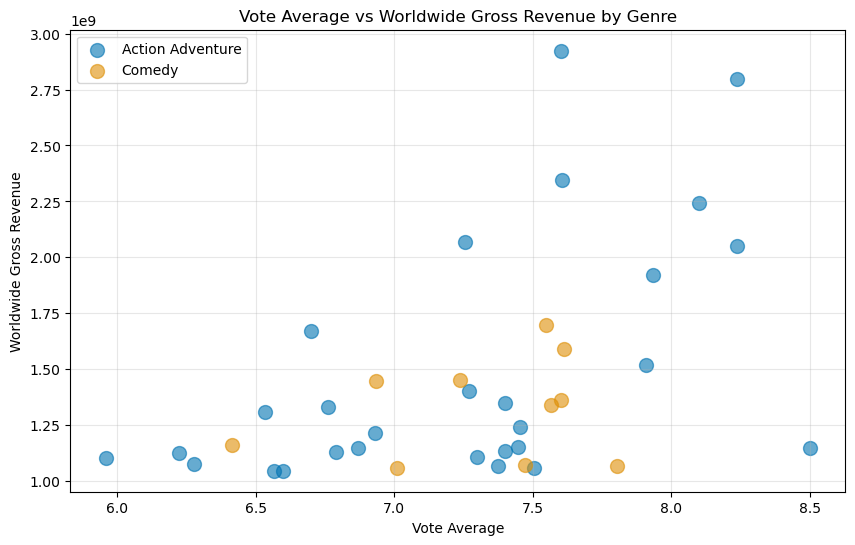

In [10]:
# answer
import matplotlib.pyplot as plt

# Filter data for action adventure movies
action_adventure_df = movies_merged2[movies_merged2['action_adventure'] == True]

# Filter data for comedy movies
comedy_df = movies_merged2[movies_merged2['comedy'] == True]

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Plot action adventure movies (using colorblind-friendly blue)
plt.scatter(action_adventure_df['Vote_Average'], action_adventure_df['gross_nums_clean'], 
           color='#0173B2', label='Action Adventure', alpha=0.6, s=100)

# Plot comedy movies (using colorblind-friendly orange)
plt.scatter(comedy_df['Vote_Average'], comedy_df['gross_nums_clean'], 
           color='#DE8F05', label='Comedy', alpha=0.6, s=100)

# Add labels and title
plt.xlabel('Vote Average')
plt.ylabel('Worldwide Gross Revenue')
plt.title('Vote Average vs Worldwide Gross Revenue by Genre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Question #1

A movie company wants to make a film with the highest revenue and is considering making either an action adventure or a comedy film. Based on your analyses above, which genre should they choose? Explain your reasoning using the analyses above. You may also add additional analyses to support your answer.

**To obtain full marks (4 points):**
- Clearly state which genre you recommend (1 point)
- Reference and correctly interpret the mean gross revenue values for both genres (1 point)
- Reference and correctly interpret the median gross revenue values for both genres (1 point)
- Provide clear reasoning for your recommendation, discuss why mean or median might be more appropriate for this decision, and acknowledge any limitations or additional considerations (1 point)

### Sample Answer:

This is a nuanced decision. Action adventure films have a higher mean gross revenue ($1,490,158,871 vs $1,324,228,191), but comedy films have a higher median gross revenue ($1,349,476,690 vs $1,228,808,306). 

The higher mean for action adventure suggests that some action adventure films perform exceptionally well (potential outliers pulling the mean up), while the higher median for comedy suggests that a typical comedy film tends to perform better than a typical action adventure film. 

If the company wants to maximize potential revenue and is willing to take more risk, they might choose action adventure. However, if they want more consistent, reliable performance, comedy might be the safer choice. 

The decision should also consider production costs, market saturation, and the company's expertise in each genre.

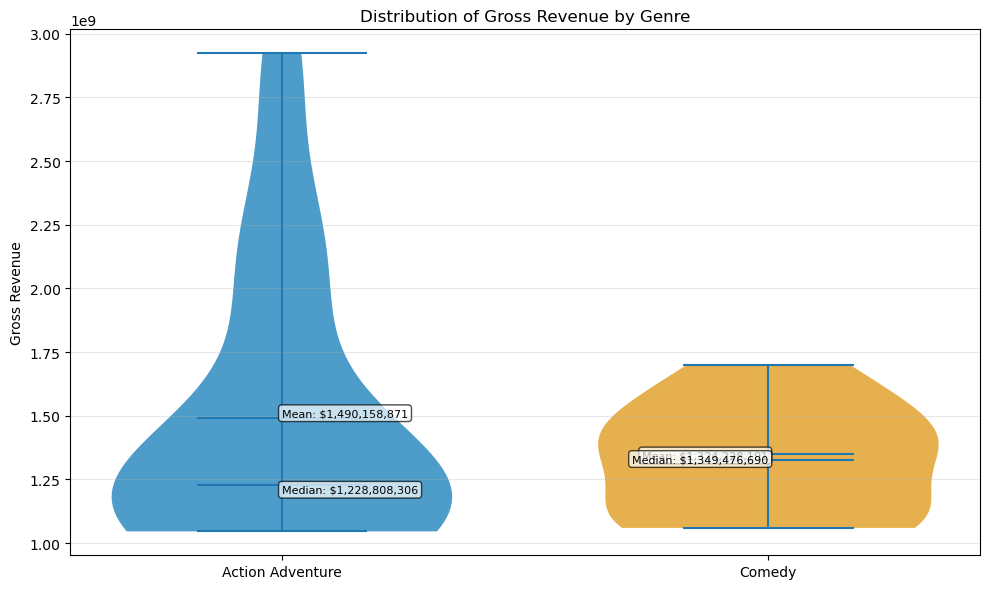

Action Adventure movies: n=28
  Mean: $1,490,158,871
  Median: $1,228,808,306

Comedy movies: n=10
  Mean: $1,324,228,191
  Median: $1,349,476,690


In [11]:
# Optional: Additional analysis to support the answer
# Compare the distribution of gross revenues for both genres

import matplotlib.pyplot as plt

# Prepare data for violin plot
action_adventure_revenues = movies_merged2[movies_merged2['action_adventure'] == True]['gross_nums_clean']
comedy_revenues = movies_merged2[movies_merged2['comedy'] == True]['gross_nums_clean']

# Create violin plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create violin plot
parts = ax.violinplot([action_adventure_revenues, comedy_revenues], 
                       positions=[1, 2], 
                       showmeans=True, 
                       showmedians=True,
                       widths=0.7)

# Color the violins
parts['bodies'][0].set_facecolor('#0173B2')
parts['bodies'][0].set_alpha(0.7)
parts['bodies'][1].set_facecolor('#DE8F05')
parts['bodies'][1].set_alpha(0.7)

# Add labels and formatting
ax.set_xticks([1, 2])
ax.set_xticklabels(['Action Adventure', 'Comedy'])
ax.set_ylabel('Gross Revenue')
ax.set_title('Distribution of Gross Revenue by Genre')
ax.grid(True, alpha=0.3, axis='y')

# Add text showing mean and median values
ax.text(1, action_adventure_mean_gross, f'Mean: ${action_adventure_mean_gross:,.0f}', 
        ha='left', va='bottom', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(1, action_adventure_median_gross, f'Median: ${action_adventure_median_gross:,.0f}', 
        ha='left', va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(2, comedy_mean_gross, f'Mean: ${comedy_mean_gross:,.0f}', 
        ha='right', va='bottom', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(2, comedy_median_gross, f'Median: ${comedy_median_gross:,.0f}', 
        ha='right', va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Action Adventure movies: n={len(action_adventure_revenues)}")
print(f"  Mean: ${action_adventure_mean_gross:,.0f}")
print(f"  Median: ${action_adventure_median_gross:,.0f}")
print()
print(f"Comedy movies: n={len(comedy_revenues)}")
print(f"  Mean: ${comedy_mean_gross:,.0f}")
print(f"  Median: ${comedy_median_gross:,.0f}")

### TA Grading Rubric for Question #1

**Total Points: 4**

**Genre Selection (1 point):**
- Student clearly states which genre they recommend (action adventure or comedy)
- Note: Either answer can be acceptable if properly justified

**Use of Mean Values (1 point):**
- Student references the mean gross revenue values for both genres in their answer
- Student correctly interprets which genre has higher mean revenue (action adventure has higher mean)

**Use of Median Values (1 point):**
- Student references the median gross revenue values for both genres in their answer
- Student correctly interprets which genre has higher median revenue (comedy has higher median)

**Reasoning and Explanation (1 point):**
- Student provides clear reasoning for their recommendation
- Student discusses why mean or median might be more appropriate for this decision
- Student acknowledges the difference between mean and median results
- Student considers potential limitations or factors (e.g., outliers, variability, risk tolerance)

**Sample Strong Answer:**
This is a nuanced decision. Action adventure films have a higher mean gross revenue ($1,490,158,871 vs $1,324,228,191), but comedy films have a higher median gross revenue ($1,349,476,690 vs $1,228,808,306). The higher mean for action adventure suggests that some action adventure films perform exceptionally well (potential outliers pulling the mean up), while the higher median for comedy suggests that a typical comedy film tends to perform better than a typical action adventure film. If the company wants to maximize potential revenue and is willing to take more risk, they might choose action adventure. However, if they want more consistent, reliable performance, comedy might be the safer choice. The decision should also consider production costs, market saturation, and the company's expertise in each genre.